In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Importing Data Frame
df = pd.read_pickle('/Users/javieraquezada/Desktop/Retail Analysis/02 Data/cleaned_sample.pkl')

In [3]:
# This option ensures that the graphs you create are displayed within the notebook without the need to "call" them specifically.

%matplotlib inline

In [4]:
df

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
77037,8154457,18745,Tara Wright,Jeffrey100@gmail.com,6.443965e+09,474 Kevin Road Apt. 786,Chicago,Connecticut,14063.0,USA,...,2350.802482,Books,HarperCollins,Fiction,Excellent,Standard,PayPal,Processing,5.0,Historical fiction
106765,8896002,82300,Daniel Patton,Cheyenne19@gmail.com,1.792779e+09,717 Timothy Prairie,Brisbane,New South Wales,82508.0,Australia,...,605.991344,Clothing,Zara,Jeans,Excellent,Same-Day,Debit Card,Shipped,5.0,Wide-leg jeans
187652,1820950,49584,Kathleen Watson,Billy97@gmail.com,2.066960e+09,2069 Nicholas Prairie Suite 877,St. John's,Ontario,61208.0,Canada,...,676.659578,Grocery,Pepsi,Water,Bad,Standard,Credit Card,Shipped,1.0,Mineral water
184582,9448636,74580,Steven Sullivan,Gabriel71@gmail.com,8.490832e+09,912 Randall Manor,Saskatoon,Ontario,53361.0,Canada,...,272.016496,Home Decor,Bed Bath & Beyond,Bedding,Bad,Standard,Credit Card,Shipped,1.0,Mattress topper
290216,8088692,72061,Heather Yu,Daniel32@gmail.com,7.141601e+09,1297 Willis Drive,Halifax,Ontario,64745.0,Canada,...,2394.895305,Grocery,Nestle,Snacks,Good,Standard,Debit Card,Shipped,4.0,Chips
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265038,8840651,38662,Kathy Ellis,Michelle59@gmail.com,8.856982e+09,690 Kevin Course,Hamburg,Berlin,58244.0,Germany,...,1752.600327,Electronics,Mitsubhisi,Mitsubishi 1.5 Ton 3 Star Split AC,Excellent,Same-Day,Credit Card,Delivered,5.0,Mini-split AC
78419,7259568,91292,Megan Collins,Michaela13@gmail.com,8.443722e+09,346 Velazquez Rest,Chicago,Connecticut,29933.0,USA,...,1758.932459,Clothing,Nike,Shorts,Bad,Standard,Cash,Delivered,1.0,Cargo shorts
210348,9767759,30124,James Warner,Jamie63@gmail.com,8.068852e+09,0685 Albert Fords,Hamilton,Ontario,36526.0,Canada,...,3172.002246,Home Decor,Home Depot,Tools,Average,Standard,PayPal,Pending,2.0,Level
133716,2867588,94521,Gina Villanueva,Daniel17@gmail.com,7.696473e+09,513 Smith Rest Suite 565,London,Ontario,97524.0,Canada,...,78.200892,Grocery,Nestle,Coffee,Good,Express,PayPal,Delivered,4.0,Coffee beans


In [5]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address',
       'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income',
       'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases',
       'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand',
       'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method',
       'Order_Status', 'Ratings', 'products'],
      dtype='object')

In [6]:
df.head(20)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
77037,8154457,18745,Tara Wright,Jeffrey100@gmail.com,6.443965e+09,474 Kevin Road Apt. 786,Chicago,Connecticut,14063.0,USA,...,2350.802482,Books,HarperCollins,Fiction,Excellent,Standard,PayPal,Processing,5.0,Historical fiction
106765,8896002,82300,Daniel Patton,Cheyenne19@gmail.com,1.792779e+09,717 Timothy Prairie,Brisbane,New South Wales,82508.0,Australia,...,605.991344,Clothing,Zara,Jeans,Excellent,Same-Day,Debit Card,Shipped,5.0,Wide-leg jeans
187652,1820950,49584,Kathleen Watson,Billy97@gmail.com,2.066960e+09,2069 Nicholas Prairie Suite 877,St. John's,Ontario,61208.0,Canada,...,676.659578,Grocery,Pepsi,Water,Bad,Standard,Credit Card,Shipped,1.0,Mineral water
184582,9448636,74580,Steven Sullivan,Gabriel71@gmail.com,8.490832e+09,912 Randall Manor,Saskatoon,Ontario,53361.0,Canada,...,272.016496,Home Decor,Bed Bath & Beyond,Bedding,Bad,Standard,Credit Card,Shipped,1.0,Mattress topper
290216,8088692,72061,Heather Yu,Daniel32@gmail.com,7.141601e+09,1297 Willis Drive,Halifax,Ontario,64745.0,Canada,...,2394.895305,Grocery,Nestle,Snacks,Good,Standard,Debit Card,Shipped,4.0,Chips
82858,3187054,56374,Margaret Johnson,Michael14@gmail.com,1.636710e+09,9004 Adam Pine Suite 517,Chicago,Connecticut,27684.0,USA,...,3274.191065,Home Decor,Home Depot,Tools,Excellent,Express,Cash,Processing,4.0,Screwdriver set
267257,6367885,65313,Elizabeth Mccullough,Michael69@gmail.com,5.519756e+09,96901 Dawson Unions,Adelaide,New South Wales,44735.0,Australia,...,474.378138,Electronics,Mitsubhisi,Mitsubishi 1.5 Ton 3 Star Split AC,Good,Express,Credit Card,Delivered,3.0,Mini-split AC
178197,9623932,83702,Lynn Burke,Christopher26@gmail.com,6.345755e+09,208 Jacqueline Parkway Suite 710,Manchester,England,35840.0,UK,...,1389.733291,Grocery,Coca-Cola,Water,Average,Same-Day,PayPal,Processing,2.0,Artesian water
2633,8679098,43096,Mrs. Stephanie Ruiz,Jesse4@gmail.com,3.445443e+09,75707 Brandon Mews Suite 673,Portsmouth,England,18212.0,UK,...,3128.578441,Clothing,Nike,Shorts,Excellent,Standard,Cash,Shipped,4.0,Denim shorts
174864,7439059,85705,Alexandria Watts,Mary24@gmail.com,8.027151e+09,7593 Amber Shoal,Nottingham,England,17024.0,UK,...,50.176370,Home Decor,Bed Bath & Beyond,Bathroom,Bad,Standard,Credit Card,Delivered,1.0,Mirror


In [7]:
df.shape

(9759, 30)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9759 entries, 77037 to 136190
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Transaction_ID    9759 non-null   Int64   
 1   Customer_ID       9759 non-null   Int64   
 2   Name              9759 non-null   object  
 3   Email             9759 non-null   object  
 4   Phone             9759 non-null   float64 
 5   Address           9759 non-null   object  
 6   City              9759 non-null   object  
 7   State             9759 non-null   object  
 8   Zipcode           9759 non-null   float64 
 9   Country           9759 non-null   object  
 10  Age               9759 non-null   float64 
 11  Gender            9759 non-null   object  
 12  Income            9759 non-null   object  
 13  Customer_Segment  9759 non-null   object  
 14  Date              9759 non-null   object  
 15  Year              9759 non-null   float64 
 16  Month             9759 

In [9]:
# Check for missing values

df.isnull().sum()

Transaction_ID      0
Customer_ID         0
Name                0
Email               0
Phone               0
Address             0
City                0
State               0
Zipcode             0
Country             0
Age                 0
Gender              0
Income              0
Customer_Segment    0
Date                0
Year                0
Month               0
Time                0
Total_Purchases     0
Amount              0
Total_Amount        0
Product_Category    0
Product_Brand       0
Product_Type        0
Feedback            0
Shipping_Method     0
Payment_Method      0
Order_Status        0
Ratings             0
products            0
dtype: int64

In [10]:
dups = df.duplicated()

In [11]:
dups.shape # No dups

(9759,)

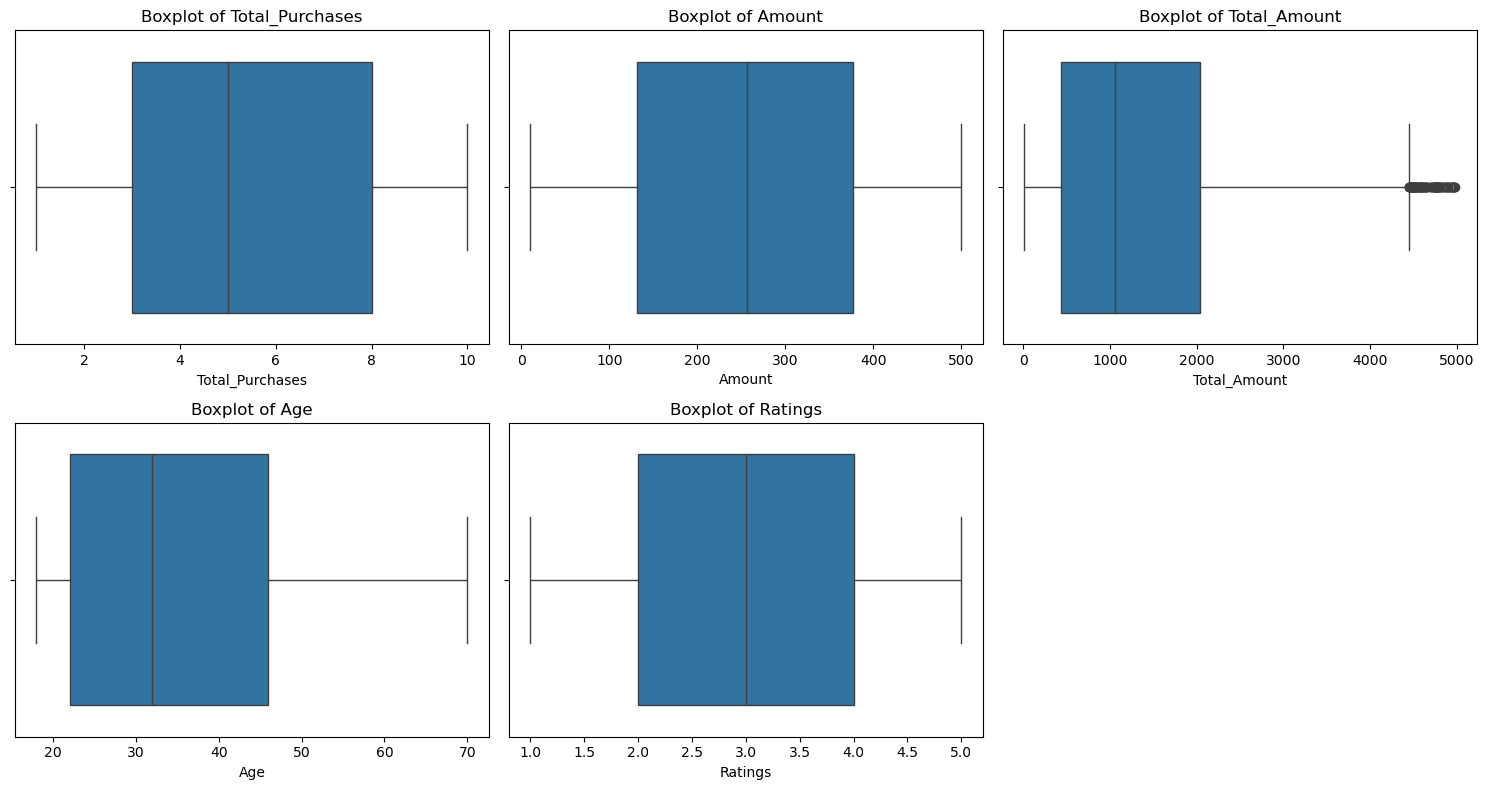

Total_Purchases outliers count: 0
Amount outliers count: 0
Total_Amount outliers count: 92
Age outliers count: 0
Ratings outliers count: 0


In [12]:
# Extreme Values Check


# Columns to check
cols = ['Total_Purchases', 'Amount', 'Total_Amount', 'Age', 'Ratings']

# 1. Boxplots for visualizing extremes
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. Detecting outliers using IQR
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers

# Print number of outliers per column
for col in cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col} outliers count: {len(outliers)}")

In [13]:
## Given that the max Total_Amount is around 4983 (which could be realistic for high spenders), it might just be some heavy spenders rather than data errors.

In [14]:
## Checking outliers individually just in case
# Assuming you already have your 'outliers' boolean mask for Total_Amount
outliers_total_amount = (df['Total_Amount'] > df['Total_Amount'].quantile(0.99))  # top 1% as example

# Extract those rows
outlier_rows = df[outliers_total_amount]

# Show summary info and some sample rows
print(outlier_rows[['Customer_ID', 'Total_Amount', 'Total_Purchases', 'Age', 'Gender']].describe())
print(outlier_rows.head(10))

        Customer_ID  Total_Amount  Total_Purchases        Age
count          98.0     98.000000        98.000000  98.000000
mean   51655.408163   4672.554397         9.908163  35.551020
std    26569.236967    167.241829         0.290280  14.914963
min         10586.0   4440.658927         9.000000  19.000000
25%        26522.75   4515.643744        10.000000  22.000000
50%         48042.0   4647.431589        10.000000  33.500000
75%         71926.5   4789.705527        10.000000  46.000000
max         99760.0   4983.048474        10.000000  70.000000
        Transaction_ID  Customer_ID             Name                 Email  \
83658          8936649        46733       Brenda Kim    Thomas80@gmail.com   
106351         9301998        87306  Richard Skinner   Matthew93@gmail.com   
198569         1465650        28833    Vincent Doyle  Kimberly63@gmail.com   
133412         5512542        53696    Kathleen Beck      Ryan42@gmail.com   
195787         1518407        24224  Danielle Torres

In [15]:
##### Observations on Outliers in Total_Amount

#All identified outliers have very high purchase amounts (above 4,400), which aligns with the top 1% of the dataset.
#The `Total_Purchases` for these entries is mostly 9 or 10, near the dataset's maximum.
#The age of these customers ranges from 19 to 70, which falls within the expected adult age range.
#These outliers come from diverse countries, including the USA, UK, Canada, Germany, and Australia.
#Product categories and brands vary widely, covering groceries (Pepsi), electronics (Apple, Sony), clothing (Zara, Nike), and books.
#Customer feedback for these entries is mixed, ranging from "Good" and "Excellent" to "Bad" and "Average".
#Ratings also vary between 1 and 4.

### Interpretation: These outliers represent high-value, frequent customers rather than data errors or anomalies. 
#Their presence is reasonable, reflecting loyal customers or big spenders in the dataset.
#Given their meaningful contribution, it makes sense to keep them in the regression analysis, 
#but we should be aware that they may influence the model results. 

#####To ensure robustness, it is recommended to fit regression models both with and without these outliers and compare the outcomes.

In [17]:
## Cheking median, mean and max
columns = ['Total_Purchases', 'Amount', 'Total_Amount', 'Age', 'Ratings']

for col in columns:
    mean_val = df[col].mean()
    median_val = df[col].median()
    max_val = df[col].max()
    print(f"{col} - Mean: {mean_val}, Median: {median_val}, Max: {max_val}")

Total_Purchases - Mean: 5.394200225432933, Median: 5.0, Max: 10.0
Amount - Mean: 254.65856519730707, Median: 256.6646488, Max: 499.9966805
Total_Amount - Mean: 1374.0137453106106, Median: 1053.939697, Max: 4983.048474
Age - Mean: 35.43682754380572, Median: 32.0, Max: 70.0
Ratings - Mean: 3.1567783584383644, Median: 3.0, Max: 5.0


In [18]:
## These values help us understand the central tendencies and the range of our data. 
#The means and medians being close suggests fairly symmetric distributions for most variables, 
#except possibly Total_Amount, which has a higher max indicating some high spenders.

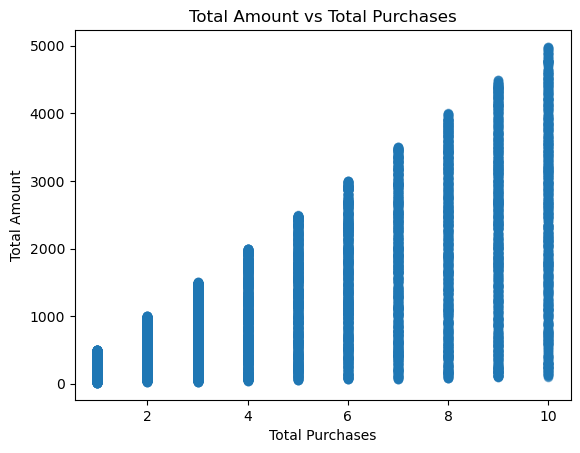

In [21]:
## 4. Exploring Data Visually 
plt.scatter(df['Total_Purchases'], df['Total_Amount'], alpha=0.5)
plt.title('Total Amount vs Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Total Amount')
plt.show()

In [19]:
#### Hypothesis :  
#There is a positive correlation between the number of purchases and the total amount spent by customers.  
#We expect that customers who make more purchases will spend more money overall.

In [23]:
## 6. Reshaping the variables into Numpy arrays , with x being the independent variable and y being the dependent

X = df['Total_Purchases'].values.reshape(-1, 1)  # Independent variable
y = df['Total_Amount'].values  # Dependent variable

In [24]:
X

array([[7.],
       [7.],
       [7.],
       ...,
       [9.],
       [1.],
       [6.]])

In [25]:
y

array([2350.802482  ,  605.9913443 ,  676.659578  , ..., 3172.002246  ,
         78.20089151, 1950.065223  ])

In [26]:
## 7. Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
###8. Regression Analysis

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
# Predicting on test set
y_pred = model.predict(X_test)

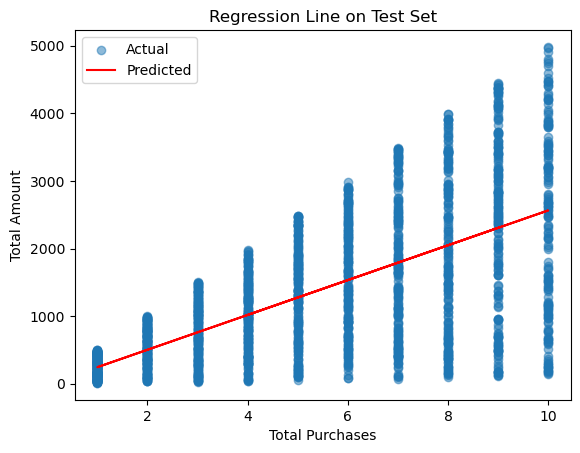

In [30]:
# 9. Creating a plot that shows the regression line on the test set
plt.scatter(X_test, y_test, alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title('Regression Line on Test Set')
plt.xlabel('Total Purchases')
plt.ylabel('Total Amount')
plt.legend()
plt.show()

In [31]:
# Step 11 
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

# Create a DataFrame comparing actual vs predicted
comparison_df = pd.DataFrame({
    'Actual_Total_Amount': y_test.flatten(),
    'Predicted_Total_Amount': y_pred.flatten()
})

print(comparison_df.head(10))  # show first 10 rows

Mean Squared Error: 754769.5601671883
R2 Score: 0.3969925138359618
   Actual_Total_Amount  Predicted_Total_Amount
0          1451.765088             1017.074998
1           972.572166             1017.074998
2           798.515440             1017.074998
3           278.909077             1274.848779
4            57.489330              243.753657
5           835.577437              501.527437
6           135.451861              501.527437
7           247.997834             1274.848779
8           484.027022             1274.848779
9          3993.864842             2048.170120


In [38]:
# Step 12. Comparisong in a dataframe.
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df.head(10)

,Actual,Predicted
0,1451.765088,1017.074998
1,972.572166,1017.074998
2,798.515440,1017.074998
3,278.909077,1274.848779
4,57.489330,243.753657
5,835.577437,501.527437
6,135.451861,501.527437
7,247.997834,1274.848779
8,484.027022,1274.848779
9,3993.864842,2048.170120


In [35]:
#13. Thoughts on how well the model performed
### Interpretation of Linear Regression Results

#The model’s Mean Squared Error (MSE) is quite high, 
#meaning the average difference between the actual and predicted total amounts is large.
#This tells us the model makes some noticeable errors in prediction.
#Overall, the model shows a moderate fit
#it’s useful to predict spending from purchases, but there’s room for improvement by including more variables or using different models.

#The analysis shows that when customers buy more things, they usually spend more money overall.
#So, there is a clear positive connection between the number of purchases and the total amount spent.
#But, the predictions from the model aren’t super accurate. 
#There’s quite a bit of difference between what the model predicts and the actual amounts spent. 
#The model explains about 40% of the spending based on the number of purchases, which means other factors are also important.
#In short, the number of purchases helps us understand spending, but we’d need more information to predict spending better.

In [36]:
# The rest of the 60% is influenced by other things the model didnt include, could be costumer income, product types,discounts, gender, etc.

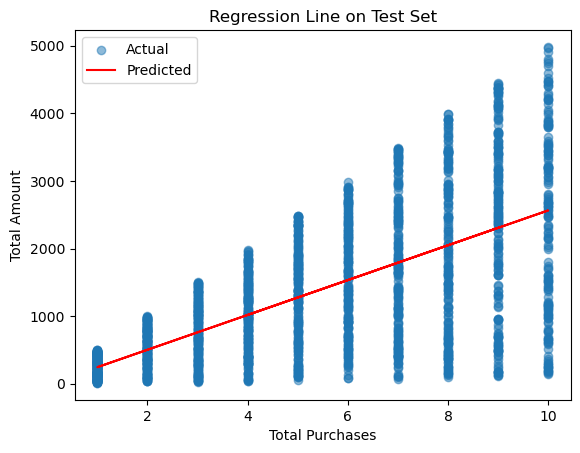

In [41]:
##Saving viz

path = os.path.expanduser('~/Desktop/regression_line_test_set.png')

plt.scatter(X_test, y_test, alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.title('Regression Line on Test Set')
plt.xlabel('Total Purchases')
plt.ylabel('Total Amount')
plt.legend()
plt.savefig(path) 
plt.show()